### Bagging Algorithms Implemented in this Notebook:

- Random Forest: The most popular bagging algorithm that adds an extra layer of randomness (feature selection) to standard bagging.

- Standard Bagging (Bootstrap Aggregation): Uses decision trees with bootstrap sampling (sampling with replacement).

- Extra Trees (Extremely Randomized Trees): Similar to Random Forest but chooses split points completely at random, often reducing variance further.

- Pasting: An ensemble technique similar to bagging but uses sampling without replacement.

- Random Subspaces: Trains base estimators on random subsets of features rather than samples (ideal for high-dimensional data).

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification # For creating synthetic dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier

#### 2) Data Generation:

In [2]:
X, y = make_classification(n_samples= 10000,
                          n_features= 20,
                          n_informative= 15,
                          n_redundant= 5,
                          n_classes= 2,
                          random_state= 42)

In [3]:
X

array([[  1.0066906 ,   0.40535402,   0.45972838, ...,   1.36273455,
          1.2718852 ,  -1.27004543],
       [  3.20361849,  -0.707863  ,  -0.159855  , ...,   0.24223595,
          3.27233622, -12.61574921],
       [  0.08083857,  -1.29733668,   5.95839033, ...,  -2.80354839,
          1.31491339, -16.0431802 ],
       ...,
       [  2.54541477,   1.24540612,  -2.97974416, ...,   0.79300517,
         -2.87988532,   6.53447619],
       [ -0.08806484,   0.24743861,   5.39447635, ...,  -5.28256486,
          0.09068846,  -9.07602359],
       [  4.84897237,   2.7975459 ,  -4.37699838, ...,   1.68960533,
          1.13020495,  -0.94703559]], shape=(10000, 20))

In [5]:
print(X.shape)

(10000, 20)


In [4]:
y

array([1, 1, 0, ..., 0, 0, 1], shape=(10000,))

In [6]:
print(y.shape)

(10000,)


#### 3) Train Test Split:

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 20)
(2000, 20)
(8000,)
(2000,)


#### 4) Models:

In [9]:
# Creating a dictionary of models for looping:

models = {
    'Random Forest': RandomForestClassifier(n_estimators= 100,
                                           random_state= 42),

    'Standard Bagging (Decision Tree)': BaggingClassifier(estimator= DecisionTreeClassifier(),
                                                         n_estimators= 100,
                                                         bootstrap= True, # Sampling with Replacement
                                                         random_state= 42),

    'Extra Tress': ExtraTreesClassifier(n_estimators= 100,
                                       random_state= 42),

    'Pasting': BaggingClassifier(estimator= DecisionTreeClassifier(), # Similar to Bagging, but samples are drawn WITHOUT replacement
                                n_estimators= 100,
                                bootstrap= False, # Sampling without replacement
                                random_state= 42),

    'Random Subspaces': BaggingClassifier(estimator= DecisionTreeClassifier(), # Sampling features rather than samples (bootstrap=False, max_features < 1.0)
                                         n_estimators= 100,
                                         bootstrap= False, # Use all samples
                                         max_features= 0.7, # Use only 70% of features per estimator
                                         random_state= 42)
}

In [10]:
# Model Training and Evaluation:

results = []

for name, model in models.items():
    model.fit(X_train, y_train) # Fitting the model
    y_pred = model.predict(X_test) # Predictions using the model
    acc = accuracy_score(y_test, y_pred) # Model Accuracy
    results.append({'Algorithm': name, 'Accuracy': acc})
    print(f"{name:<35} | {acc:.4f}")

Random Forest                       | 0.9485
Standard Bagging (Decision Tree)    | 0.9390
Extra Tress                         | 0.9550
Pasting                             | 0.8720
Random Subspaces                    | 0.9445


##### 5) Result Visualization:

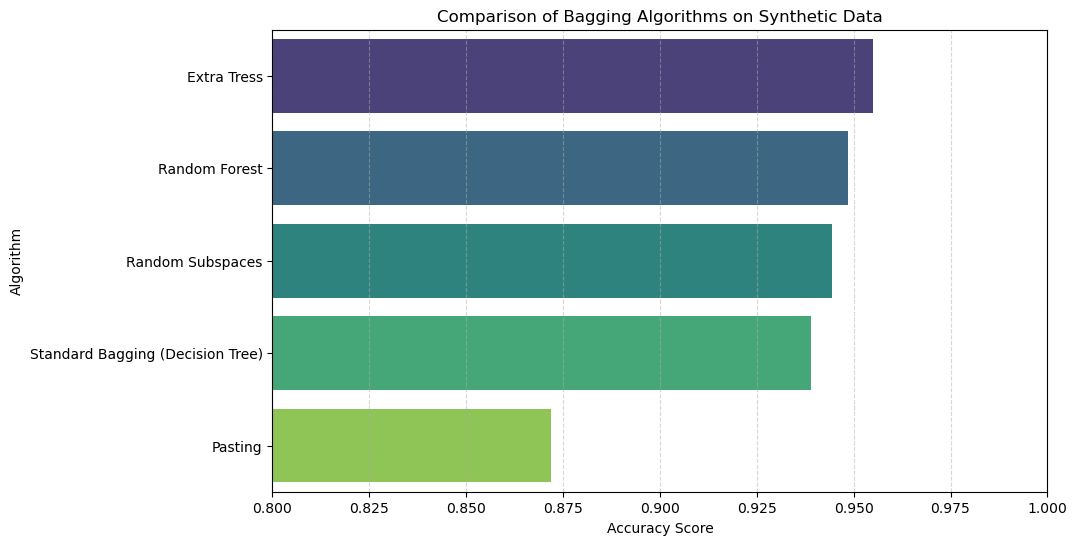

In [15]:
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize= (10, 6))
sns.barplot(x= 'Accuracy', y= 'Algorithm', data= df_results, palette= 'viridis', hue= 'Algorithm')
plt.title('Comparison of Bagging Algorithms on Synthetic Data')
plt.xlabel('Accuracy Score')
plt.xlim(0.8, 1.0) # Zoom in to see differences
plt.grid(axis= 'x', linestyle= '--', alpha= 0.5)
plt.show()

#### Best Model and Report of Evaluation:

In [16]:
best_model_name = df_results.iloc[0]['Algorithm']
print(f"\n{'-'*60}")
print(f"Detailed Report for Best Model: {best_model_name}")
print(f"{'-'*60}")
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))


------------------------------------------------------------
Detailed Report for Best Model: Extra Tress
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1001
           1       0.96      0.95      0.95       999

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.96      0.95      0.95      2000

